Fitting 5 folds for each of 36 candidates, totalling 180 fits
Test set accuracy: 0.9981

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       157
           1       1.00      1.00      1.00       822
           2       1.00      0.99      0.99        71

    accuracy                           1.00      1050
   macro avg       1.00      0.99      1.00      1050
weighted avg       1.00      1.00      1.00      1050


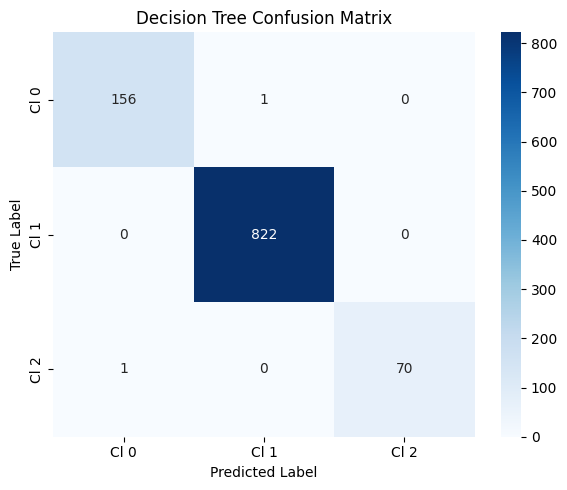


--- Decision Tree Structure ---

|--- Steps <= 11.50
|   |--- PAM Score <= 1.47
|   |   |--- PAM Score <= 1.28
|   |   |   |--- class: 1
|   |   |--- PAM Score >  1.28
|   |   |   |--- Steps <= 9.50
|   |   |   |   |--- Steps <= 7.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- Steps >  7.50
|   |   |   |   |   |--- PAM Score <= 1.34
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- PAM Score >  1.34
|   |   |   |   |   |   |--- Steps <= 8.50
|   |   |   |   |   |   |   |--- PAM Score <= 1.41
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |--- PAM Score >  1.41
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- Steps >  8.50
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |--- Steps >  9.50
|   |   |   |   |--- class: 0
|   |--- PAM Score >  1.47
|   |   |--- Steps <= 3.50
|   |   |   |--- PAM Score <= 1.78
|   |   |   |   |--- class: 1
|   |   |   |--- PAM Score >  1.78
|   |   |   |   |--- class: 0
|   |

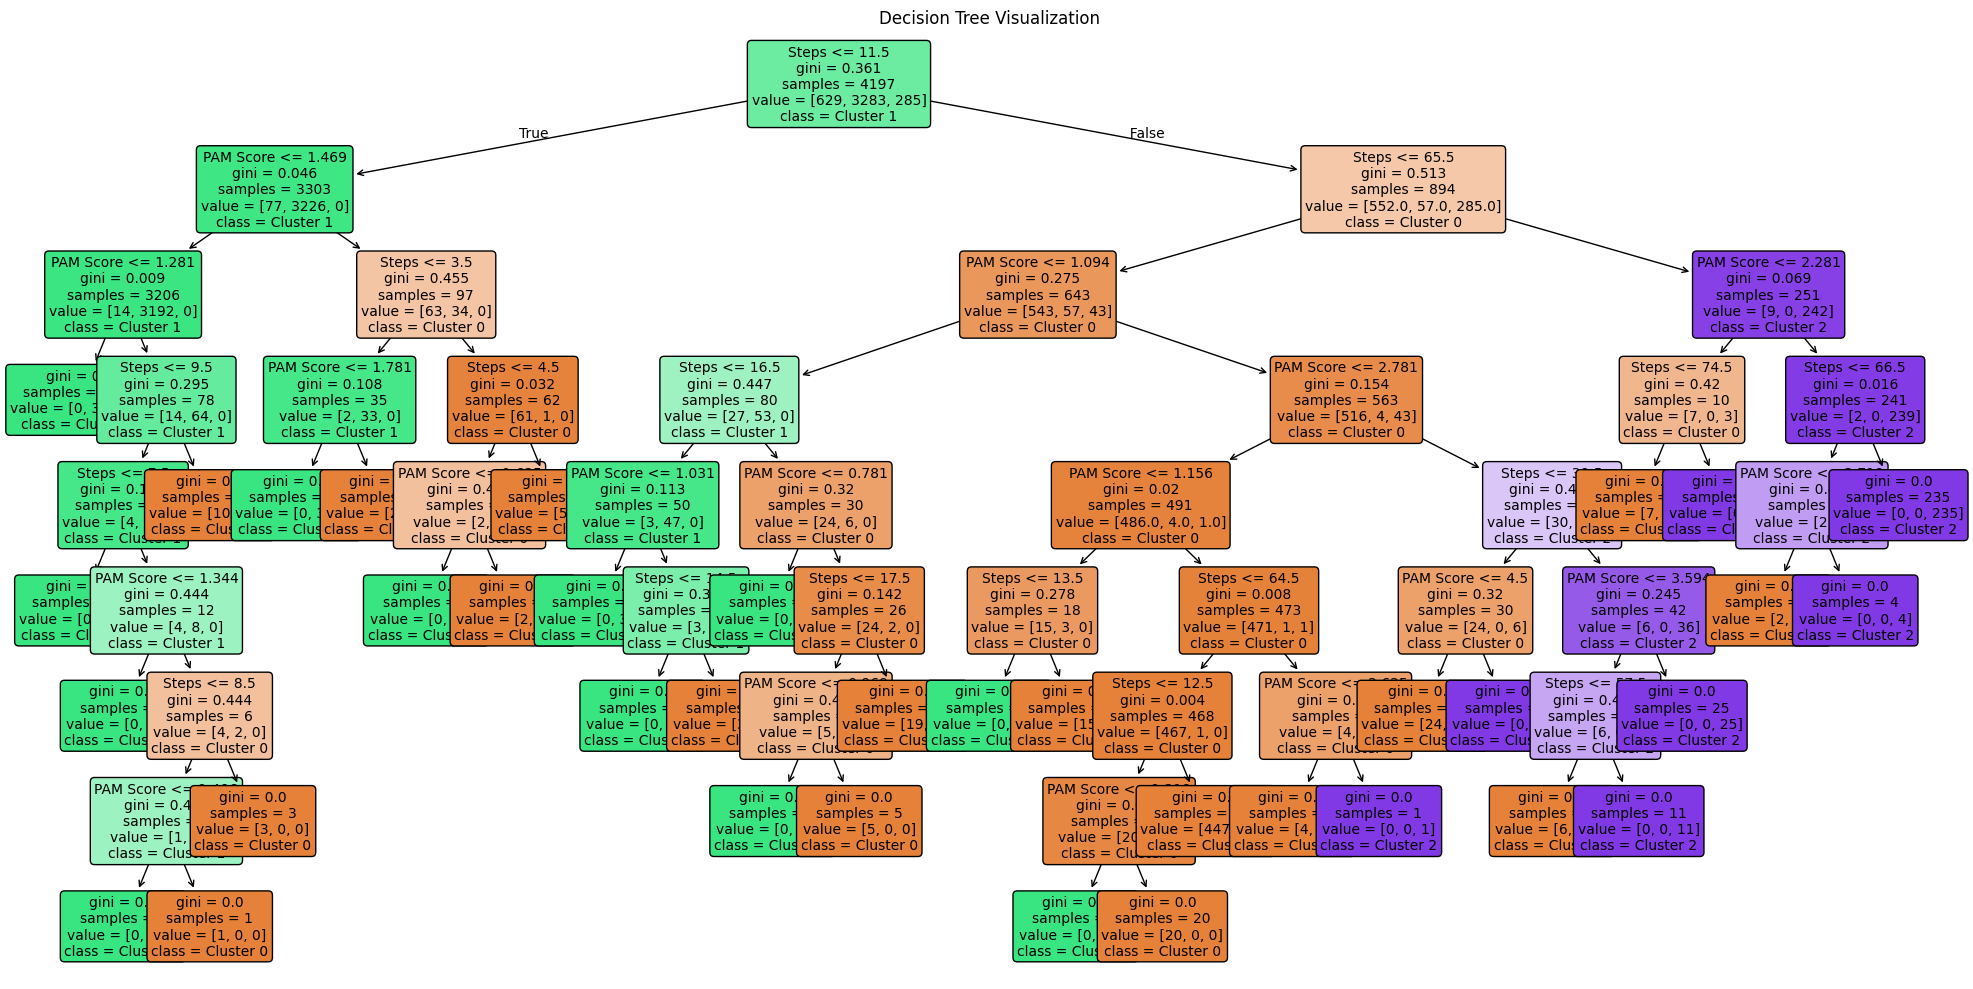

Trained decision tree saved to 'decision_tree_model.joblib'


In [28]:
# train_and_save_decision_tree.py

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# =============================================================================
# 1) LOAD THE LABELED CSV
# =============================================================================

CSV_PATH = 'clustered_output_k3.csv'  # ← Change to your CSV path if needed
df = pd.read_csv(CSV_PATH)

# Drop any helper columns (e.g., "DateOnly")
for col in ['DateOnly']:
    if col in df.columns:
        df = df.drop(columns=[col])

# Convert "Timestamp" to datetime, then drop (unless you plan to engineer time features)
if 'Timestamp' in df.columns:
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
    df = df.drop(columns=['Timestamp'])

# =============================================================================
# 2) DEFINE FEATURES (X) AND TARGET (y)
# =============================================================================

TARGET_COLUMN = 'tabel'
if TARGET_COLUMN not in df.columns:
    raise ValueError(f"Expected target column '{TARGET_COLUMN}' not found in DataFrame")

y = df[TARGET_COLUMN].astype(int)
X = df.drop(columns=[TARGET_COLUMN])

# Drop any non-numeric columns just in case
non_numeric_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric_cols:
    X = X.drop(columns=non_numeric_cols)

# =============================================================================
# 3) SPLIT INTO TRAIN/TEST SETS
# =============================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =============================================================================
# 4) HYPERPARAMETER TUNING FOR DECISION TREE
# =============================================================================

param_grid = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

dtree = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(
    estimator=dtree,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
best_tree = grid_search.best_estimator_

# =============================================================================
# 5) EVALUATE ON TEST SET
# =============================================================================

y_pred = best_tree.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Test set accuracy: {acc:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=sorted(y.unique()))
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[f'Cl {c}' for c in sorted(y.unique())],
    yticklabels=[f'Cl {c}' for c in sorted(y.unique())]
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Decision Tree Confusion Matrix')
plt.tight_layout()
plt.show()

# =============================================================================
# 6) PRINT THE DECISION TREE TEXTUALLY
# =============================================================================

feature_names = X.columns.tolist()
tree_text = export_text(best_tree, feature_names=feature_names)
print("\n--- Decision Tree Structure ---\n")
print(tree_text)

# =============================================================================
# 7) VISUALIZE THE TREE
# =============================================================================

plt.figure(figsize=(20, 10))
plot_tree(
    best_tree,
    feature_names=feature_names,
    class_names=[f'Cluster {c}' for c in sorted(y.unique())],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Visualization")
plt.tight_layout()
plt.show()

# =============================================================================
# 8) SAVE THE TRAINED MODEL TO DISK
# =============================================================================

MODEL_PATH = 'decision_tree_model.joblib'
joblib.dump(best_tree, MODEL_PATH)
print(f"Trained decision tree saved to '{MODEL_PATH}'")
